In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42

OUTPUT_DIR = "coursework2_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

file_path = r"C:\Users\DELL\Downloads\appliances+energy+prediction\energydata_complete.csv"
df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Rows and columns:", df.shape)

display(df.head())
display(df.tail())

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Dataset loaded successfully.
Rows and columns: (19735, 29)


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
19730,2016-05-27 17:20:00,100,0,25.566667,46.560000,25.890000,42.025714,27.200000,41.163333,24.7,...,23.2,46.7900,22.733333,755.2,55.666667,3.333333,23.666667,13.333333,43.096812,43.096812
19731,2016-05-27 17:30:00,90,0,25.500000,46.500000,25.754000,42.080000,27.133333,41.223333,24.7,...,23.2,46.7900,22.600000,755.2,56.000000,3.500000,24.500000,13.300000,49.282940,49.282940
19732,2016-05-27 17:40:00,270,10,25.500000,46.596667,25.628571,42.768571,27.050000,41.690000,24.7,...,23.2,46.7900,22.466667,755.2,56.333333,3.666667,25.333333,13.266667,29.199117,29.199117
19733,2016-05-27 17:50:00,420,10,25.500000,46.990000,25.414000,43.036000,26.890000,41.290000,24.7,...,23.2,46.8175,22.333333,755.2,56.666667,3.833333,26.166667,13.233333,6.322784,6.322784
19734,2016-05-27 18:00:00,430,10,25.500000,46.600000,25.264286,42.971429,26.823333,41.156667,24.7,...,23.2,46.8450,22.200000,755.2,57.000000,4.000000,27.000000,13.200000,34.118851,34.118851



Column names:
['date', 'Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'rv1', 'rv2']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  object 
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         1

In [3]:
# I clean the date column and check basic data quality before doing analysis.

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.sort_values("date").reset_index(drop=True)

print("Date range:")
print(df["date"].min(), "to", df["date"].max())

print("\nRows and columns after sorting:")
print(df.shape)

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nTotal missing values:")
print(df.isna().sum().sum())

schema_table = pd.DataFrame({
    "Column": df.columns,
    "Data type": df.dtypes.astype(str),
    "Missing values": df.isna().sum().values,
    "Missing %": (df.isna().mean().values * 100).round(3),
    "Unique values": df.nunique().values
})

display(schema_table)

schema_table.to_csv(f"{OUTPUT_DIR}/table_1_schema_validation.csv", index=False)

Date range:
2016-01-11 17:00:00 to 2016-05-27 18:00:00

Rows and columns after sorting:
(19735, 29)

Duplicate rows:
0

Total missing values:
0


,Column,Data type,Missing values,Missing %,Unique values
date,date,datetime64[ns],0,0.0,19735
Appliances,Appliances,int64,0,0.0,92
lights,lights,int64,0,0.0,8
T1,T1,float64,0,0.0,722
RH_1,RH_1,float64,0,0.0,2547
T2,T2,float64,0,0.0,1650
RH_2,RH_2,float64,0,0.0,3376
T3,T3,float64,0,0.0,1426
RH_3,RH_3,float64,0,0.0,2618
T4,T4,float64,0,0.0,1390


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Appliances,19735.0,97.694958,102.524891,10.000000,50.000000,60.000000,100.000000,1080.000000,3.386367,13.667863
lights,19735.0,3.801875,7.935988,0.000000,0.000000,0.000000,0.000000,70.000000,2.195155,4.462147
T1,19735.0,21.686571,1.606066,16.790000,20.760000,21.600000,22.600000,26.260000,0.120917,0.161601
RH_1,19735.0,40.259739,3.979299,27.023333,37.333333,39.656667,43.066667,63.360000,0.465774,0.112629
T2,19735.0,20.341219,2.192974,16.100000,18.790000,20.000000,21.500000,29.856667,0.889658,0.933397
RH_2,19735.0,40.420420,4.069813,20.463333,37.900000,40.500000,43.260000,56.026667,-0.268247,0.670959
T3,19735.0,22.267611,2.006111,17.200000,20.790000,22.100000,23.290000,29.236000,0.450777,-0.007055
RH_3,19735.0,39.242500,3.254576,28.766667,36.900000,38.530000,41.760000,50.163333,0.467589,-0.583126
T4,19735.0,20.855335,2.042884,15.100000,19.530000,20.666667,22.100000,26.200000,0.170384,-0.037633
RH_4,19735.0,39.026904,4.341321,27.660000,35.530000,38.400000,42.156667,51.090000,0.444614,-0.613967


,Metric,Value
0,count,19735.000000
1,mean,97.694958
2,median,60.000000
3,standard deviation,102.524891
4,minimum,10.000000
5,25%,50.000000
6,75%,100.000000
7,maximum,1080.000000
8,skewness,3.386367
9,kurtosis,13.667863


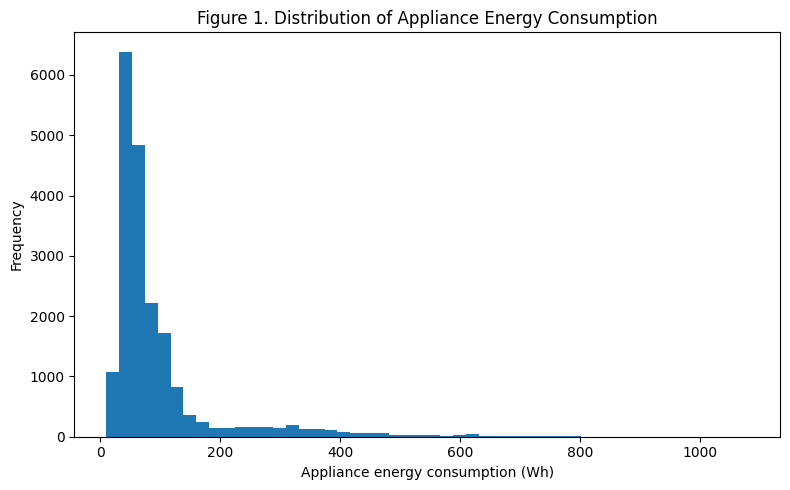

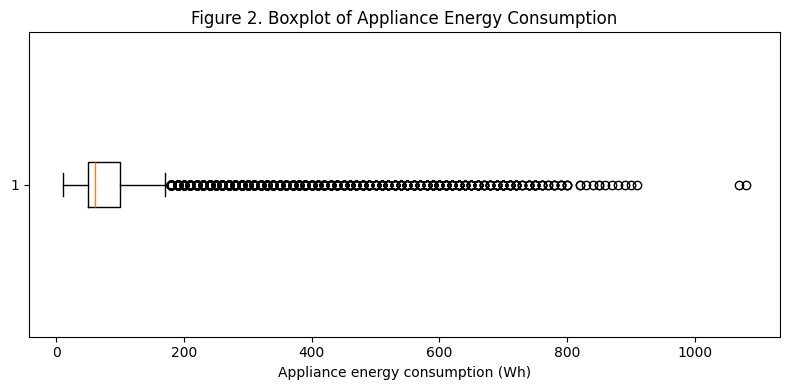

In [4]:
# I summarise the numeric variables and inspect the target variable before modelling.

target = "Appliances"

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

descriptive_table = df[numeric_cols].describe().T
descriptive_table["skewness"] = df[numeric_cols].skew()
descriptive_table["kurtosis"] = df[numeric_cols].kurtosis()

display(descriptive_table)

descriptive_table.to_csv(f"{OUTPUT_DIR}/table_2_descriptive_statistics.csv")

target_summary = pd.DataFrame({
    "Metric": [
        "count", "mean", "median", "standard deviation",
        "minimum", "25%", "75%", "maximum",
        "skewness", "kurtosis"
    ],
    "Value": [
        df[target].count(),
        df[target].mean(),
        df[target].median(),
        df[target].std(),
        df[target].min(),
        df[target].quantile(0.25),
        df[target].quantile(0.75),
        df[target].max(),
        df[target].skew(),
        df[target].kurtosis()
    ]
})

display(target_summary)

target_summary.to_csv(f"{OUTPUT_DIR}/table_3_target_summary.csv", index=False)

plt.figure(figsize=(8, 5))
plt.hist(df[target], bins=50)
plt.xlabel("Appliance energy consumption (Wh)")
plt.ylabel("Frequency")
plt.title("Figure 1. Distribution of Appliance Energy Consumption")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure_1_appliance_energy_distribution.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 4))
plt.boxplot(df[target], vert=False)
plt.xlabel("Appliance energy consumption (Wh)")
plt.title("Figure 2. Boxplot of Appliance Energy Consumption")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure_2_appliance_energy_boxplot.png", dpi=300)
plt.show()

,Feature,Description
0,hour,Hour of the day
1,day,Day of the month
2,month,Month number
3,weekday,Day of the week where Monday=0 and Sunday=6
4,is_weekend,Weekend flag where 1=weekend and 0=weekday
5,season,Season derived from month


,hour,Appliances
0,0,52.785888
1,1,51.326034
2,2,49.075426
3,3,48.236010
4,4,49.355231
5,5,52.737226
6,6,57.712895
7,7,78.649635
8,8,106.143552
9,9,112.785888


,weekday,Appliances
0,0,111.450684
1,1,87.125000
2,2,89.930556
3,3,90.434028
4,4,104.622144
5,5,106.246345
6,6,94.915936


,date,Appliances
0,2016-01-11,136.666667
1,2016-01-12,85.694444
2,2016-01-13,97.013889
3,2016-01-14,151.388889
4,2016-01-15,125.347222


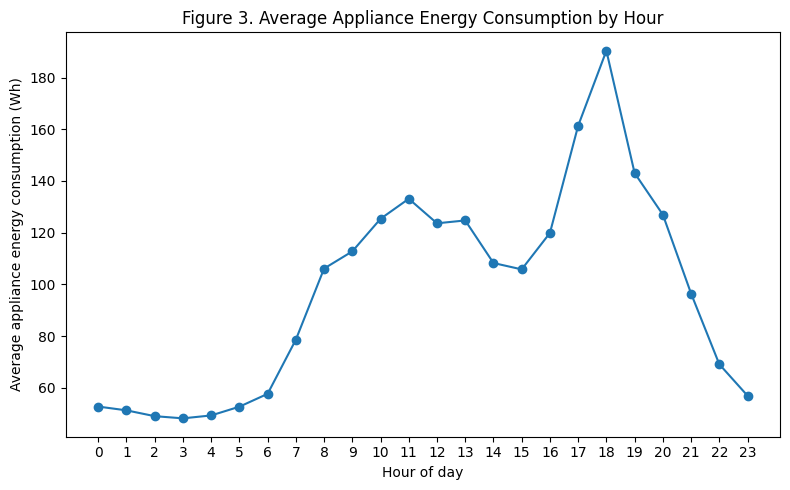

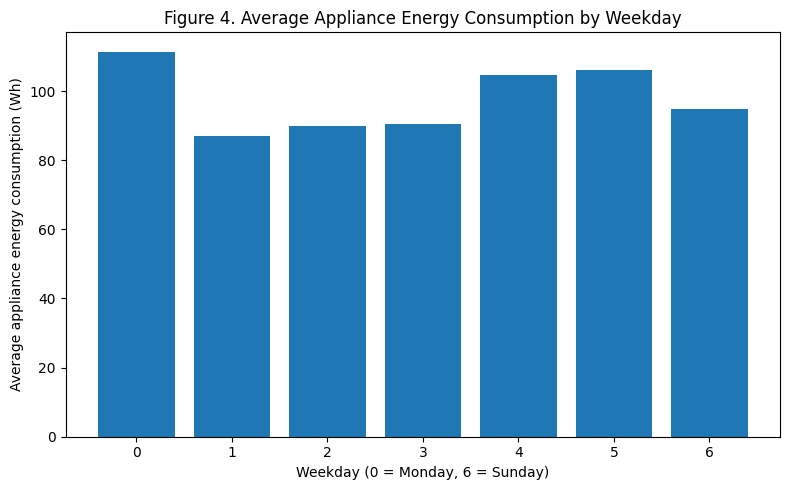

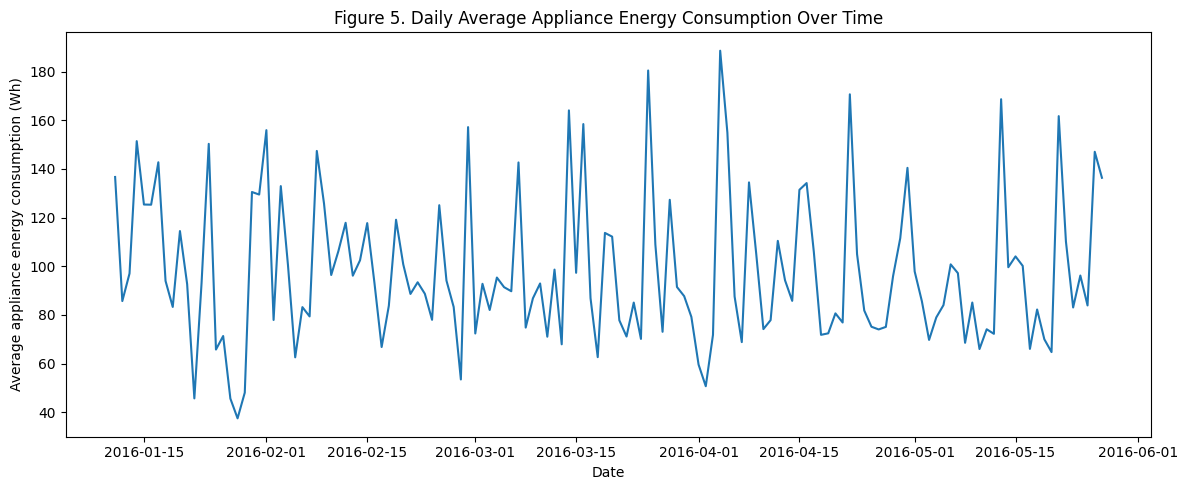

In [5]:
# I create time-based features so I can understand how energy use changes over time.

data = df.copy()

data["hour"] = data["date"].dt.hour
data["day"] = data["date"].dt.day
data["month"] = data["date"].dt.month
data["weekday"] = data["date"].dt.weekday
data["is_weekend"] = data["weekday"].isin([5, 6]).astype(int)

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

data["season"] = data["month"].apply(get_season)

time_feature_summary = pd.DataFrame({
    "Feature": ["hour", "day", "month", "weekday", "is_weekend", "season"],
    "Description": [
        "Hour of the day",
        "Day of the month",
        "Month number",
        "Day of the week where Monday=0 and Sunday=6",
        "Weekend flag where 1=weekend and 0=weekday",
        "Season derived from month"
    ]
})

display(time_feature_summary)
time_feature_summary.to_csv(f"{OUTPUT_DIR}/table_4_time_features_summary.csv", index=False)

hourly_avg = data.groupby("hour")["Appliances"].mean().reset_index()
weekday_avg = data.groupby("weekday")["Appliances"].mean().reset_index()

daily_trend = data.groupby(data["date"].dt.date)["Appliances"].mean().reset_index()
daily_trend["date"] = pd.to_datetime(daily_trend["date"])

display(hourly_avg)
display(weekday_avg)
display(daily_trend.head())

hourly_avg.to_csv(f"{OUTPUT_DIR}/table_5_hourly_average_consumption.csv", index=False)
weekday_avg.to_csv(f"{OUTPUT_DIR}/table_6_weekday_average_consumption.csv", index=False)
daily_trend.to_csv(f"{OUTPUT_DIR}/table_7_daily_average_consumption.csv", index=False)

plt.figure(figsize=(8, 5))
plt.plot(hourly_avg["hour"], hourly_avg["Appliances"], marker="o")
plt.xlabel("Hour of day")
plt.ylabel("Average appliance energy consumption (Wh)")
plt.title("Figure 3. Average Appliance Energy Consumption by Hour")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure_3_hourly_energy_trend.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(weekday_avg["weekday"], weekday_avg["Appliances"])
plt.xlabel("Weekday (0 = Monday, 6 = Sunday)")
plt.ylabel("Average appliance energy consumption (Wh)")
plt.title("Figure 4. Average Appliance Energy Consumption by Weekday")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure_4_weekday_energy_trend.png", dpi=300)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(daily_trend["date"], daily_trend["Appliances"])
plt.xlabel("Date")
plt.ylabel("Average appliance energy consumption (Wh)")
plt.title("Figure 5. Daily Average Appliance Energy Consumption Over Time")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure_5_daily_energy_trend.png", dpi=300)
plt.show()

,Metric,Value
0,Q1,50.00
1,Q3,100.00
2,IQR,50.00
3,Lower bound,-25.00
4,Upper bound,175.00
5,Outlier count,2138.00
6,Outlier %,10.83


,Feature,Correlation_with_Appliances
0,Appliances,1.000000
1,lights,0.197278
2,T2,0.120073
3,T6,0.117638
4,T_out,0.099155
5,Windspeed,0.087122
6,RH_1,0.086031
7,T3,0.085060
8,T1,0.055447
9,T4,0.040281


Top positive correlations:


,Feature,Correlation_with_Appliances
1,lights,0.197278
2,T2,0.120073
3,T6,0.117638
4,T_out,0.099155
5,Windspeed,0.087122
6,RH_1,0.086031
7,T3,0.085060
8,T1,0.055447
9,T4,0.040281
10,T8,0.039572


Top negative correlations:


,Feature,Correlation_with_Appliances
28,RH_out,-0.152282
27,RH_8,-0.094039
26,RH_6,-0.083178
25,RH_2,-0.060465
24,RH_7,-0.055642
23,RH_9,-0.051462
22,Press_mm_hg,-0.034885
20,rv1,-0.011145
21,rv2,-0.011145
19,Visibility,0.000230


Correlation between rv1 and rv2: 1.0


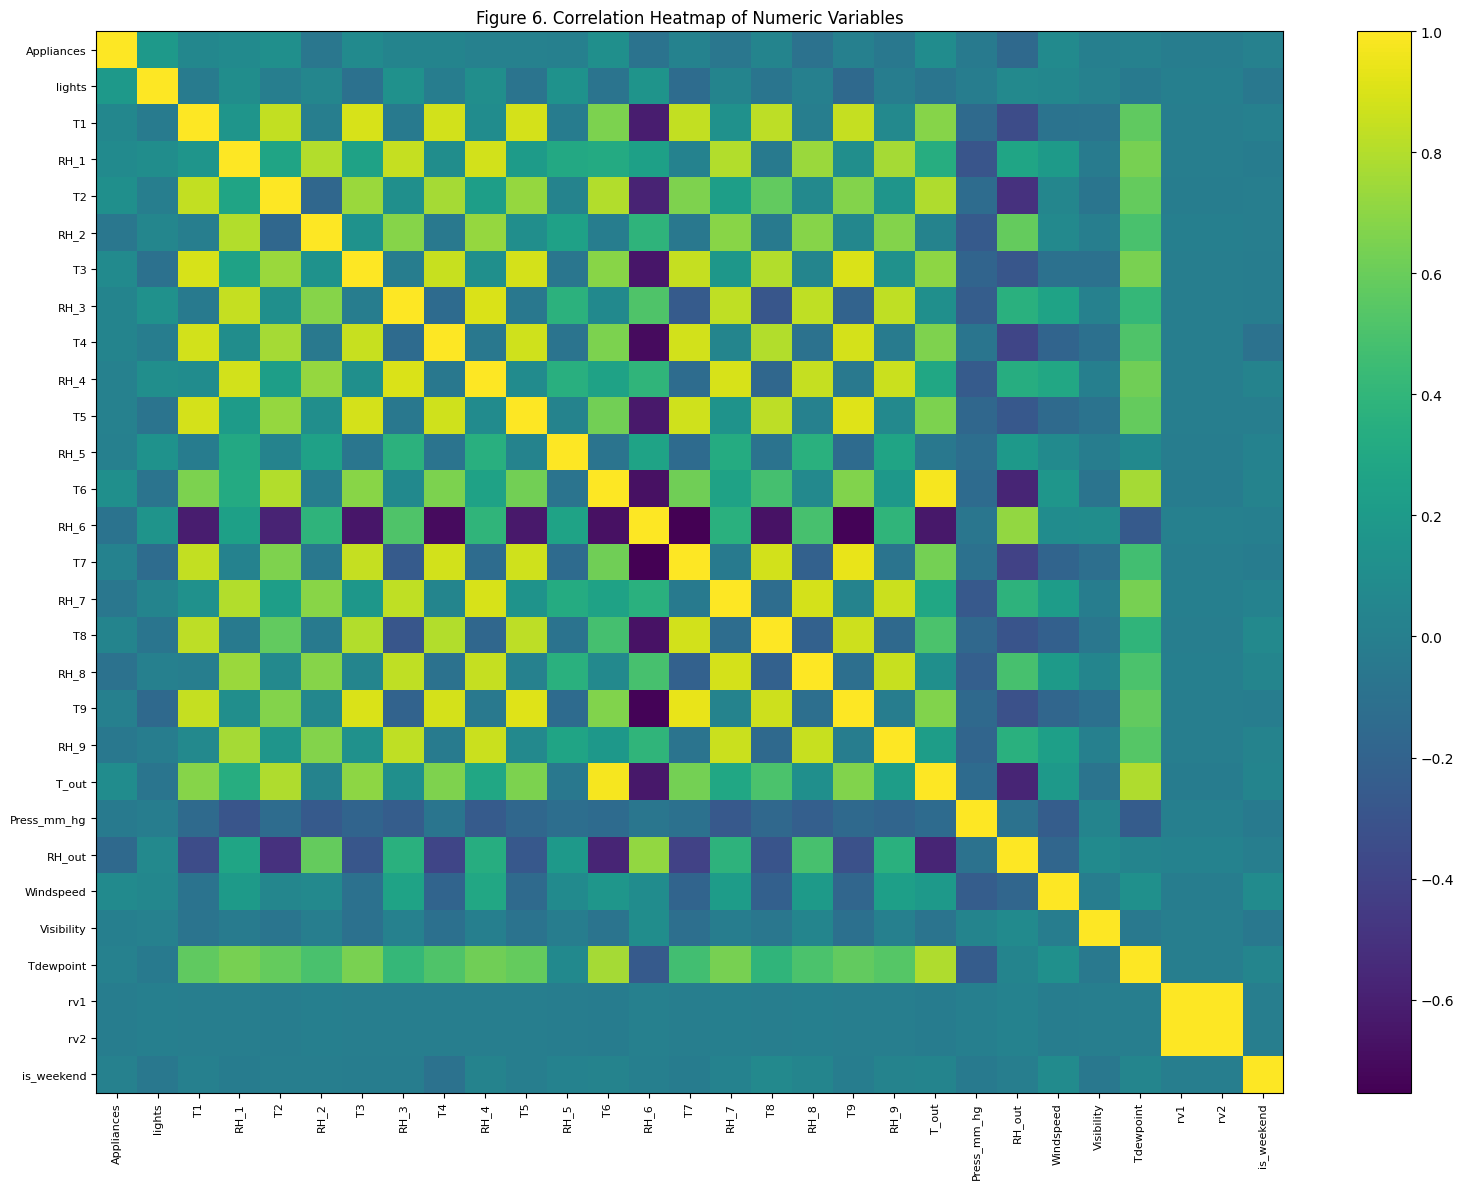

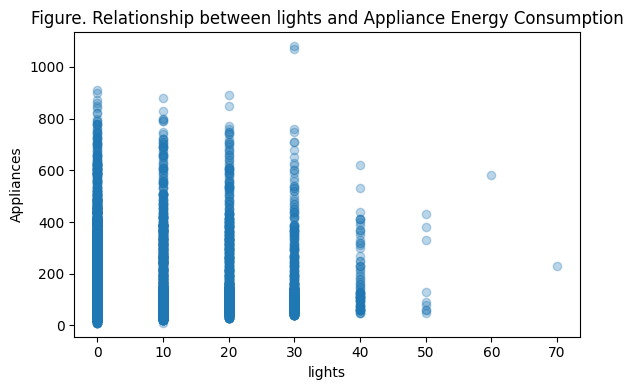

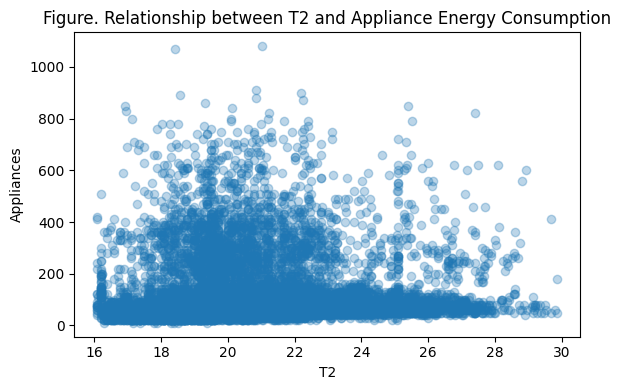

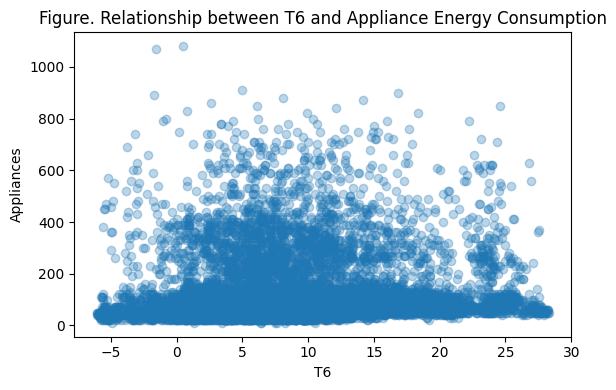

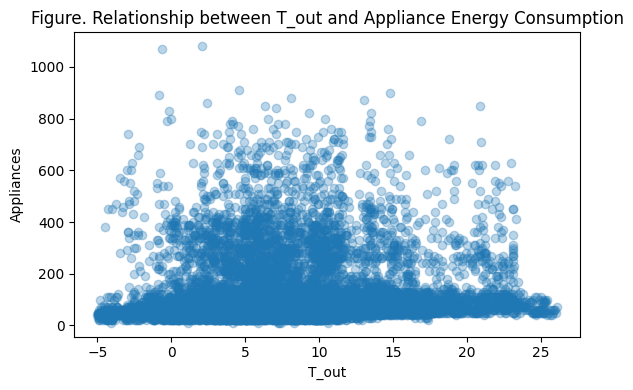

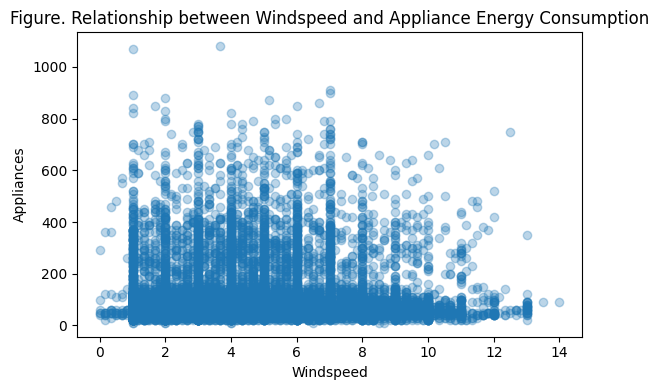

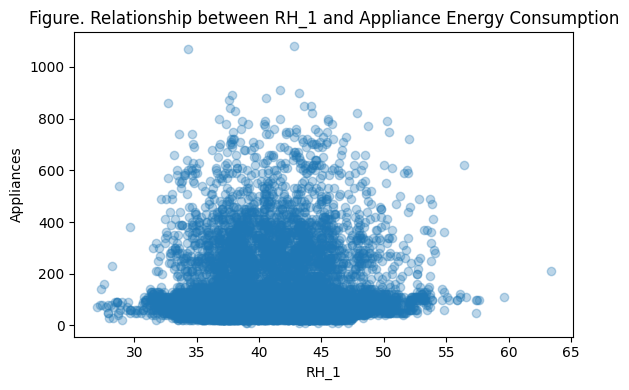

In [6]:
# I now check outliers and the strength of relationships between variables.

target = "Appliances"

Q1 = data[target].quantile(0.25)
Q3 = data[target].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_count = ((data[target] < lower_bound) | (data[target] > upper_bound)).sum()
outlier_percent = round((outlier_count / len(data)) * 100, 2)

outlier_summary = pd.DataFrame({
    "Metric": ["Q1", "Q3", "IQR", "Lower bound", "Upper bound", "Outlier count", "Outlier %"],
    "Value": [Q1, Q3, IQR, lower_bound, upper_bound, outlier_count, outlier_percent]
})

display(outlier_summary)
outlier_summary.to_csv(f"{OUTPUT_DIR}/table_8_outlier_summary.csv", index=False)

numeric_data = data.select_dtypes(include=["int64", "float64"]).copy()

correlation_with_target = numeric_data.corr()[target].sort_values(ascending=False).reset_index()
correlation_with_target.columns = ["Feature", "Correlation_with_Appliances"]

display(correlation_with_target)

correlation_with_target.to_csv(f"{OUTPUT_DIR}/table_9_correlation_with_target.csv", index=False)

top_positive = correlation_with_target[correlation_with_target["Feature"] != target].head(10)
top_negative = correlation_with_target.sort_values("Correlation_with_Appliances").head(10)

print("Top positive correlations:")
display(top_positive)

print("Top negative correlations:")
display(top_negative)

# I also check whether rv1 and rv2 are effectively the same variable.
rv_correlation = data[["rv1", "rv2"]].corr().iloc[0, 1]
print("Correlation between rv1 and rv2:", rv_correlation)

corr_matrix = numeric_data.corr()

plt.figure(figsize=(16, 12))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90, fontsize=8)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns, fontsize=8)
plt.title("Figure 6. Correlation Heatmap of Numeric Variables")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure_6_correlation_heatmap.png", dpi=300)
plt.show()

top_features = correlation_with_target[
    (correlation_with_target["Feature"] != target)
].head(6)["Feature"].tolist()

for feature in top_features:
    plt.figure(figsize=(6, 4))
    plt.scatter(data[feature], data[target], alpha=0.3)
    plt.xlabel(feature)
    plt.ylabel("Appliances")
    plt.title(f"Figure. Relationship between {feature} and Appliance Energy Consumption")
    plt.tight_layout()
    safe_name = feature.replace("/", "_").replace(" ", "_")
    plt.savefig(f"{OUTPUT_DIR}/scatter_{safe_name}_vs_appliances.png", dpi=300)
    plt.show()

In [7]:
# I check multicollinearity before finalising the modelling features.

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = data.select_dtypes(include=["int64", "float64"]).copy()

# I remove the target and the duplicate random variable before calculating VIF.
vif_features = vif_data.drop(columns=["Appliances", "rv2"])

# I use a sample to keep the VIF calculation fast and stable.
vif_sample = vif_features.sample(n=min(5000, len(vif_features)), random_state=RANDOM_STATE)

vif_table = pd.DataFrame()
vif_table["Feature"] = vif_sample.columns
vif_table["VIF"] = [
    variance_inflation_factor(vif_sample.values, i)
    for i in range(vif_sample.shape[1])
]

vif_table = vif_table.sort_values("VIF", ascending=False).reset_index(drop=True)

display(vif_table)

vif_table.to_csv(f"{OUTPUT_DIR}/table_10_vif_multicollinearity.csv", index=False)

high_vif_features = vif_table[vif_table["VIF"] > 10]

print("Number of features with VIF above 10:", len(high_vif_features))
display(high_vif_features)

,Feature,VIF
0,T1,3508.501694
1,T9,2587.213239
2,T2,2511.499686
3,RH_2,2149.680131
4,Press_mm_hg,2050.738035
5,T7,1679.042461
6,RH_3,1529.359692
7,RH_1,1525.210463
8,RH_4,1406.959348
9,RH_out,1276.603903


Number of features with VIF above 10: 23


,Feature,VIF
0,T1,3508.501694
1,T9,2587.213239
2,T2,2511.499686
3,RH_2,2149.680131
4,Press_mm_hg,2050.738035
5,T7,1679.042461
6,RH_3,1529.359692
7,RH_1,1525.210463
8,RH_4,1406.959348
9,RH_out,1276.603903


In [8]:
# I add time, lag, rolling, differential and interaction features for modelling.

model_data = df.copy()

model_data["date"] = pd.to_datetime(model_data["date"])
model_data = model_data.sort_values("date").reset_index(drop=True)

model_data["hour"] = model_data["date"].dt.hour
model_data["day"] = model_data["date"].dt.day
model_data["month"] = model_data["date"].dt.month
model_data["weekday"] = model_data["date"].dt.weekday
model_data["is_weekend"] = model_data["weekday"].isin([5, 6]).astype(int)

def get_season(month):
    if month in [12, 1, 2]:
        return "winter"
    elif month in [3, 4, 5]:
        return "spring"
    elif month in [6, 7, 8]:
        return "summer"
    else:
        return "autumn"

model_data["season"] = model_data["month"].apply(get_season)
model_data = pd.get_dummies(model_data, columns=["season"], drop_first=True)

# I use lag features because recent appliance use is likely to influence near-future use.
model_data["Appliances_lag_1"] = model_data["Appliances"].shift(1)
model_data["Appliances_lag_3"] = model_data["Appliances"].shift(3)
model_data["Appliances_lag_6"] = model_data["Appliances"].shift(6)

# I use rolling averages to capture short-term energy behaviour.
model_data["Appliances_roll_3"] = model_data["Appliances"].shift(1).rolling(window=3).mean()
model_data["Appliances_roll_6"] = model_data["Appliances"].shift(1).rolling(window=6).mean()
model_data["Appliances_roll_12"] = model_data["Appliances"].shift(1).rolling(window=12).mean()

temperature_columns = ["T1", "T2", "T3", "T4", "T5", "T6", "T7", "T8", "T9"]
humidity_columns = ["RH_1", "RH_2", "RH_3", "RH_4", "RH_5", "RH_6", "RH_7", "RH_8", "RH_9"]

model_data["indoor_temp_mean"] = model_data[temperature_columns].mean(axis=1)
model_data["indoor_humidity_mean"] = model_data[humidity_columns].mean(axis=1)

model_data["temp_inside_outside_diff"] = model_data["indoor_temp_mean"] - model_data["T_out"]
model_data["humidity_inside_outside_diff"] = model_data["indoor_humidity_mean"] - model_data["RH_out"]

# I add simple interactions because temperature, humidity and time can combine in nonlinear ways.
model_data["temp_humidity_interaction"] = model_data["indoor_temp_mean"] * model_data["indoor_humidity_mean"]
model_data["hour_weekend_interaction"] = model_data["hour"] * model_data["is_weekend"]

rows_before = len(model_data)
model_data = model_data.dropna().reset_index(drop=True)
rows_after = len(model_data)

print("Rows before dropping lag-related missing values:", rows_before)
print("Rows after dropping lag-related missing values:", rows_after)
print("Rows removed:", rows_before - rows_after)

print("\nFinal engineered dataset shape:")
print(model_data.shape)

new_features = [
    "hour", "day", "month", "weekday", "is_weekend",
    "Appliances_lag_1", "Appliances_lag_3", "Appliances_lag_6",
    "Appliances_roll_3", "Appliances_roll_6", "Appliances_roll_12",
    "indoor_temp_mean", "indoor_humidity_mean",
    "temp_inside_outside_diff", "humidity_inside_outside_diff",
    "temp_humidity_interaction", "hour_weekend_interaction"
]

feature_engineering_table = pd.DataFrame({
    "New feature": new_features,
    "Purpose": [
        "Captures within-day appliance usage pattern",
        "Captures day-level variation",
        "Captures seasonal month-level variation",
        "Captures weekly behaviour",
        "Separates weekday and weekend behaviour",
        "Captures immediate previous energy use",
        "Captures short delayed energy behaviour",
        "Captures one-hour delayed energy behaviour",
        "Smooths very short-term previous usage",
        "Smooths previous one-hour usage pattern",
        "Smooths previous two-hour usage pattern",
        "Represents average indoor thermal condition",
        "Represents average indoor moisture condition",
        "Measures indoor-outdoor temperature gap",
        "Measures indoor-outdoor humidity gap",
        "Captures combined thermal-humidity effect",
        "Captures whether hourly behaviour changes on weekends"
    ]
})

display(feature_engineering_table)
display(model_data.head())

feature_engineering_table.to_csv(f"{OUTPUT_DIR}/table_11_feature_engineering_summary.csv", index=False)
model_data.to_csv(f"{OUTPUT_DIR}/engineered_energy_dataset.csv", index=False)

Rows before dropping lag-related missing values: 19735
Rows after dropping lag-related missing values: 19723
Rows removed: 12

Final engineered dataset shape:
(19723, 47)


,New feature,Purpose
0,hour,Captures within-day appliance usage pattern
1,day,Captures day-level variation
2,month,Captures seasonal month-level variation
3,weekday,Captures weekly behaviour
4,is_weekend,Separates weekday and weekend behaviour
5,Appliances_lag_1,Captures immediate previous energy use
6,Appliances_lag_3,Captures short delayed energy behaviour
7,Appliances_lag_6,Captures one-hour delayed energy behaviour
8,Appliances_roll_3,Smooths very short-term previous usage
9,Appliances_roll_6,Smooths previous one-hour usage pattern


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,Appliances_lag_6,Appliances_roll_3,Appliances_roll_6,Appliances_roll_12,indoor_temp_mean,indoor_humidity_mean,temp_inside_outside_diff,humidity_inside_outside_diff,temp_humidity_interaction,hour_weekend_interaction
0,2016-01-11 19:00:00,430,50,20.133333,48.000000,19.566667,44.400000,19.890000,44.900000,19.000000,...,60.0,293.333333,176.666667,115.833333,17.185185,51.854074,11.185185,-39.145926,891.121866,0
1,2016-01-11 19:10:00,250,40,20.260000,52.726667,19.730000,45.100000,19.890000,45.493333,19.000000,...,60.0,413.333333,238.333333,146.666667,17.214907,52.675000,11.214907,-37.825000,906.795248,0
2,2016-01-11 19:20:00,100,10,20.426667,55.893333,19.856667,45.833333,20.033333,47.526667,19.000000,...,60.0,420.000000,270.000000,162.500000,17.252222,53.519815,11.252222,-36.480185,923.335738,0
3,2016-01-11 19:30:00,100,10,20.566667,53.893333,20.033333,46.756667,20.100000,48.466667,19.000000,...,70.0,260.000000,276.666667,166.666667,17.286667,53.496574,11.286667,-36.003426,924.777444,0
4,2016-01-11 19:40:00,90,10,20.730000,52.660000,20.166667,47.223333,20.200000,48.530000,18.926667,...,230.0,150.000000,281.666667,170.833333,17.310741,53.378889,11.310741,-35.621111,924.028107,0


In [9]:
# I now prepare the final feature matrix and keep the split time-aware.

target = "Appliances"

columns_to_drop = [
    "date",          # datetime is already represented through engineered time features
    "Appliances",    # target variable
    "rv2"            # duplicate of rv1
]

X = model_data.drop(columns=columns_to_drop)
y = model_data[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFinal feature names:")
print(X.columns.tolist())

n = len(model_data)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

print("\nTrain set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

print("\nTrain date range:")
print(model_data["date"].iloc[:train_end].min(), "to", model_data["date"].iloc[:train_end].max())

print("\nValidation date range:")
print(model_data["date"].iloc[train_end:val_end].min(), "to", model_data["date"].iloc[train_end:val_end].max())

print("\nTest date range:")
print(model_data["date"].iloc[val_end:].min(), "to", model_data["date"].iloc[val_end:].max())

split_summary = pd.DataFrame({
    "Split": ["Training", "Validation", "Testing"],
    "Rows": [len(X_train), len(X_val), len(X_test)],
    "Percentage": [
        round(len(X_train) / n * 100, 2),
        round(len(X_val) / n * 100, 2),
        round(len(X_test) / n * 100, 2)
    ],
    "Start date": [
        model_data["date"].iloc[:train_end].min(),
        model_data["date"].iloc[train_end:val_end].min(),
        model_data["date"].iloc[val_end:].min()
    ],
    "End date": [
        model_data["date"].iloc[:train_end].max(),
        model_data["date"].iloc[train_end:val_end].max(),
        model_data["date"].iloc[val_end:].max()
    ]
})

display(split_summary)

split_summary.to_csv(f"{OUTPUT_DIR}/table_12_time_aware_split_summary.csv", index=False)

Feature matrix shape: (19723, 44)
Target shape: (19723,)

Final feature names:
['lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'rv1', 'hour', 'day', 'month', 'weekday', 'is_weekend', 'season_winter', 'Appliances_lag_1', 'Appliances_lag_3', 'Appliances_lag_6', 'Appliances_roll_3', 'Appliances_roll_6', 'Appliances_roll_12', 'indoor_temp_mean', 'indoor_humidity_mean', 'temp_inside_outside_diff', 'humidity_inside_outside_diff', 'temp_humidity_interaction', 'hour_weekend_interaction']

Train set: (13806, 44) (13806,)
Validation set: (2958, 44) (2958,)
Test set: (2959, 44) (2959,)

Train date range:
2016-01-11 19:00:00 to 2016-04-16 15:50:00

Validation date range:
2016-04-16 16:00:00 to 2016-05-07 04:50:00

Test date range:
2016-05-07 05:00:00 to 2016-05-27 18:00:00


,Split,Rows,Percentage,Start date,End date
0,Training,13806,70.0,2016-01-11 19:00:00,2016-04-16 15:50:00
1,Validation,2958,15.0,2016-04-16 16:00:00,2016-05-07 04:50:00
2,Testing,2959,15.0,2016-05-07 05:00:00,2016-05-27 18:00:00


In [10]:
# I define the evaluation functions once so every model is judged in the same way.

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

def adjusted_r2_score(r2, n, p):
    return 1 - ((1 - r2) * (n - 1) / (n - p - 1))

def safe_mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate_predictions(model_name, split_name, y_true, y_pred, number_of_features):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    adj_r2 = adjusted_r2_score(r2, len(y_true), number_of_features)
    mape = safe_mape(y_true, y_pred)
    
    return {
        "Model": model_name,
        "Split": split_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "Adjusted_R2": adj_r2,
        "MAPE": mape
    }

def train_and_evaluate_model(model_name, model, X_train, y_train, X_val, y_val, X_test, y_test):
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)
    
    p = X_train.shape[1]
    
    results = [
        evaluate_predictions(model_name, "Train", y_train, train_pred, p),
        evaluate_predictions(model_name, "Validation", y_val, val_pred, p),
        evaluate_predictions(model_name, "Test", y_test, test_pred, p)
    ]
    
    return results, train_pred, val_pred, test_pred, model

feature_names = X_train.columns.tolist()

standard_scaler_pipeline = ColumnTransformer(
    transformers=[
        ("standard_scaler", StandardScaler(), feature_names)
    ],
    remainder="drop"
)

minmax_scaler_pipeline = ColumnTransformer(
    transformers=[
        ("minmax_scaler", MinMaxScaler(), feature_names)
    ],
    remainder="drop"
)

print("Evaluation functions and preprocessing pipelines are ready.")
print("Number of modelling features:", len(feature_names))

Evaluation functions and preprocessing pipelines are ready.
Number of modelling features: 44


In [11]:
# I begin with baseline and linear models before moving to nonlinear models.

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso

baseline_and_linear_models = {
    "Mean Baseline": DummyRegressor(strategy="mean"),
    
    "Linear Regression": Pipeline([
        ("preprocess", standard_scaler_pipeline),
        ("model", LinearRegression())
    ]),
    
    "Ridge Regression": Pipeline([
        ("preprocess", standard_scaler_pipeline),
        ("model", Ridge(alpha=1.0))
    ]),
    
    "Lasso Regression": Pipeline([
        ("preprocess", standard_scaler_pipeline),
        ("model", Lasso(alpha=0.001, max_iter=10000, random_state=RANDOM_STATE))
    ])
}

baseline_linear_results = []
baseline_linear_predictions = {}
baseline_linear_trained_models = {}

for model_name, model in baseline_and_linear_models.items():
    print("Training:", model_name)
    
    results, train_pred, val_pred, test_pred, trained_model = train_and_evaluate_model(
        model_name,
        model,
        X_train,
        y_train,
        X_val,
        y_val,
        X_test,
        y_test
    )
    
    baseline_linear_results.extend(results)
    baseline_linear_predictions[model_name] = {
        "train": train_pred,
        "validation": val_pred,
        "test": test_pred
    }
    baseline_linear_trained_models[model_name] = trained_model

baseline_linear_results_df = pd.DataFrame(baseline_linear_results)

display(baseline_linear_results_df)

baseline_linear_results_df.to_csv(
    f"{OUTPUT_DIR}/table_13_baseline_and_linear_model_results.csv",
    index=False
)

baseline_linear_test_results = baseline_linear_results_df[
    baseline_linear_results_df["Split"] == "Test"
].sort_values("RMSE")

print("Test results only:")
display(baseline_linear_test_results)

Training: Mean Baseline
Training: Linear Regression
Training: Ridge Regression
Training: Lasso Regression


,Model,Split,MAE,MSE,RMSE,R2,Adjusted_R2,MAPE
0,Mean Baseline,Train,64.276526,11405.250842,106.795369,0.000000,-0.003197,83.870497
1,Mean Baseline,Validation,53.997427,8542.316687,92.424654,-0.003429,-0.018585,67.783439
2,Mean Baseline,Test,52.834059,8265.917408,90.917091,-0.000399,-0.015504,58.956755
3,Linear Regression,Train,31.677467,4534.236526,67.336740,0.602443,0.601172,32.138410
4,Linear Regression,Validation,27.624758,3626.776018,60.222720,0.573978,0.567543,27.413478
5,Linear Regression,Test,29.731343,3748.378400,61.224002,0.546345,0.539495,28.217024
6,Ridge Regression,Train,31.673971,4534.239853,67.336764,0.602443,0.601172,32.132715
7,Ridge Regression,Validation,27.606240,3626.556774,60.220900,0.574004,0.567570,27.379925
8,Ridge Regression,Test,29.667182,3745.535244,61.200778,0.546689,0.539845,28.121809
9,Lasso Regression,Train,31.673796,4534.239273,67.336760,0.602443,0.601172,32.132052


Test results only:


,Model,Split,MAE,MSE,RMSE,R2,Adjusted_R2,MAPE
11,Lasso Regression,Test,29.637798,3743.790947,61.186526,0.546900,0.540059,28.081658
8,Ridge Regression,Test,29.667182,3745.535244,61.200778,0.546689,0.539845,28.121809
5,Linear Regression,Test,29.731343,3748.378400,61.224002,0.546345,0.539495,28.217024
2,Mean Baseline,Test,52.834059,8265.917408,90.917091,-0.000399,-0.015504,58.956755


In [12]:
# I now train tree-based models because the earlier EDA showed weak linear relationships.

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor

tree_models = {
    "Decision Tree": DecisionTreeRegressor(
        random_state=RANDOM_STATE,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=5
    ),
    
    "Random Forest": RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_estimators=200,
        max_depth=18,
        min_samples_split=5,
        min_samples_leaf=2,
        n_jobs=-1
    ),
    
    "Extra Trees": ExtraTreesRegressor(
        random_state=RANDOM_STATE,
        n_estimators=200,
        max_depth=18,
        min_samples_split=5,
        min_samples_leaf=2,
        n_jobs=-1
    ),
    
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=RANDOM_STATE,
        n_estimators=250,
        learning_rate=0.05,
        max_depth=4
    )
}

tree_results = []
tree_predictions = {}
tree_trained_models = {}

for model_name, model in tree_models.items():
    print("Training:", model_name)
    
    results, train_pred, val_pred, test_pred, trained_model = train_and_evaluate_model(
        model_name,
        model,
        X_train,
        y_train,
        X_val,
        y_val,
        X_test,
        y_test
    )
    
    tree_results.extend(results)
    tree_predictions[model_name] = {
        "train": train_pred,
        "validation": val_pred,
        "test": test_pred
    }
    tree_trained_models[model_name] = trained_model

tree_results_df = pd.DataFrame(tree_results)

display(tree_results_df)

tree_results_df.to_csv(
    f"{OUTPUT_DIR}/table_14_tree_model_results.csv",
    index=False
)

tree_test_results = tree_results_df[
    tree_results_df["Split"] == "Test"
].sort_values("RMSE")

print("Test results only:")
display(tree_test_results)

Training: Decision Tree
Training: Random Forest
Training: Extra Trees
Training: Gradient Boosting


,Model,Split,MAE,MSE,RMSE,R2,Adjusted_R2,MAPE
0,Decision Tree,Train,22.201581,2215.428168,47.068335,0.805754,0.805133,22.228378
1,Decision Tree,Validation,38.425764,7397.908234,86.011094,0.131000,0.117874,37.322992
2,Decision Tree,Test,42.448701,7957.801160,89.206509,0.036892,0.022349,37.935292
3,Random Forest,Train,16.225909,1169.137220,34.192649,0.897491,0.897164,16.769300
4,Random Forest,Validation,38.506564,5128.160468,71.611176,0.397617,0.388519,39.507532
5,Random Forest,Test,67.470089,10484.780938,102.395219,-0.268941,-0.288101,72.778145
6,Extra Trees,Train,10.708629,528.634919,22.992062,0.953650,0.953502,11.915840
7,Extra Trees,Validation,30.438675,3862.623808,62.150011,0.546274,0.539421,29.983637
8,Extra Trees,Test,38.559732,4718.888664,68.694168,0.428887,0.420264,38.145171
9,Gradient Boosting,Train,25.180248,2787.435855,52.796173,0.755601,0.754819,25.939288


Test results only:


,Model,Split,MAE,MSE,RMSE,R2,Adjusted_R2,MAPE
8,Extra Trees,Test,38.559732,4718.888664,68.694168,0.428887,0.420264,38.145171
2,Decision Tree,Test,42.448701,7957.801160,89.206509,0.036892,0.022349,37.935292
5,Random Forest,Test,67.470089,10484.780938,102.395219,-0.268941,-0.288101,72.778145
11,Gradient Boosting,Test,171.227026,49738.043288,223.020276,-5.019643,-5.110536,224.419359


In [13]:
# I test XGBoost if it is available and tune Extra Trees because it was the strongest tree model.

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

try:
    from xgboost import XGBRegressor
    xgboost_available = True
except:
    xgboost_available = False

extra_trees_param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [8, 12, 16, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.5, 0.7, 1.0]
}

tscv = TimeSeriesSplit(n_splits=5)

extra_trees_search = RandomizedSearchCV(
    estimator=ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=extra_trees_param_grid,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

print("Tuning Extra Trees...")
extra_trees_search.fit(X_train, y_train)

print("Best Extra Trees parameters:")
print(extra_trees_search.best_params_)

print("\nBest CV RMSE:")
print(-extra_trees_search.best_score_)

tuned_model_results = []
tuned_model_predictions = {}
tuned_trained_models = {}

results, train_pred, val_pred, test_pred, trained_model = train_and_evaluate_model(
    "Tuned Extra Trees",
    extra_trees_search.best_estimator_,
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test
)

tuned_model_results.extend(results)
tuned_model_predictions["Tuned Extra Trees"] = {
    "train": train_pred,
    "validation": val_pred,
    "test": test_pred
}
tuned_trained_models["Tuned Extra Trees"] = trained_model

if xgboost_available:
    print("\nTraining XGBoost...")
    
    xgb_model = XGBRegressor(
        random_state=RANDOM_STATE,
        n_estimators=300,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        n_jobs=-1
    )
    
    results, train_pred, val_pred, test_pred, trained_model = train_and_evaluate_model(
        "XGBoost",
        xgb_model,
        X_train,
        y_train,
        X_val,
        y_val,
        X_test,
        y_test
    )
    
    tuned_model_results.extend(results)
    tuned_model_predictions["XGBoost"] = {
        "train": train_pred,
        "validation": val_pred,
        "test": test_pred
    }
    tuned_trained_models["XGBoost"] = trained_model

else:
    print("\nXGBoost is not available in this environment.")

tuned_results_df = pd.DataFrame(tuned_model_results)

display(tuned_results_df)

tuned_results_df.to_csv(
    f"{OUTPUT_DIR}/table_15_tuned_and_xgboost_results.csv",
    index=False
)

tuned_test_results = tuned_results_df[
    tuned_results_df["Split"] == "Test"
].sort_values("RMSE")

print("Test results only:")
display(tuned_test_results)

Tuning Extra Trees...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Extra Trees parameters:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 0.7, 'max_depth': 8}

Best CV RMSE:
66.13290051020562

XGBoost is not available in this environment.


,Model,Split,MAE,MSE,RMSE,R2,Adjusted_R2,MAPE
0,Tuned Extra Trees,Train,27.542837,3551.387640,59.593520,0.688618,0.687623,27.861083
1,Tuned Extra Trees,Validation,26.803125,3614.765862,60.122923,0.575389,0.568976,25.970132
2,Tuned Extra Trees,Test,27.941383,3672.278924,60.599331,0.555555,0.548844,24.820968


Test results only:


,Model,Split,MAE,MSE,RMSE,R2,Adjusted_R2,MAPE
2,Tuned Extra Trees,Test,27.941383,3672.278924,60.599331,0.555555,0.548844,24.820968


,Model,Split,MAE,MSE,RMSE,R2,Adjusted_R2,MAPE
0,Mean Baseline,Train,64.276526,11405.250842,106.795369,0.000000,-0.003197,83.870497
1,Mean Baseline,Validation,53.997427,8542.316687,92.424654,-0.003429,-0.018585,67.783439
2,Mean Baseline,Test,52.834059,8265.917408,90.917091,-0.000399,-0.015504,58.956755
3,Linear Regression,Train,31.677467,4534.236526,67.336740,0.602443,0.601172,32.138410
4,Linear Regression,Validation,27.624758,3626.776018,60.222720,0.573978,0.567543,27.413478
5,Linear Regression,Test,29.731343,3748.378400,61.224002,0.546345,0.539495,28.217024
6,Ridge Regression,Train,31.673971,4534.239853,67.336764,0.602443,0.601172,32.132715
7,Ridge Regression,Validation,27.606240,3626.556774,60.220900,0.574004,0.567570,27.379925
8,Ridge Regression,Test,29.667182,3745.535244,61.200778,0.546689,0.539845,28.121809
9,Lasso Regression,Train,31.673796,4534.239273,67.336760,0.602443,0.601172,32.132052


,Model,Split,MAE,MSE,RMSE,R2,Adjusted_R2,MAPE
0,Tuned Extra Trees,Test,27.941383,3672.278924,60.599331,0.555555,0.548844,24.820968
1,Lasso Regression,Test,29.637798,3743.790947,61.186526,0.546900,0.540059,28.081658
2,Ridge Regression,Test,29.667182,3745.535244,61.200778,0.546689,0.539845,28.121809
3,Linear Regression,Test,29.731343,3748.378400,61.224002,0.546345,0.539495,28.217024
4,Extra Trees,Test,38.559732,4718.888664,68.694168,0.428887,0.420264,38.145171
5,Decision Tree,Test,42.448701,7957.801160,89.206509,0.036892,0.022349,37.935292
6,Mean Baseline,Test,52.834059,8265.917408,90.917091,-0.000399,-0.015504,58.956755
7,Random Forest,Test,67.470089,10484.780938,102.395219,-0.268941,-0.288101,72.778145
8,Gradient Boosting,Test,171.227026,49738.043288,223.020276,-5.019643,-5.110536,224.419359


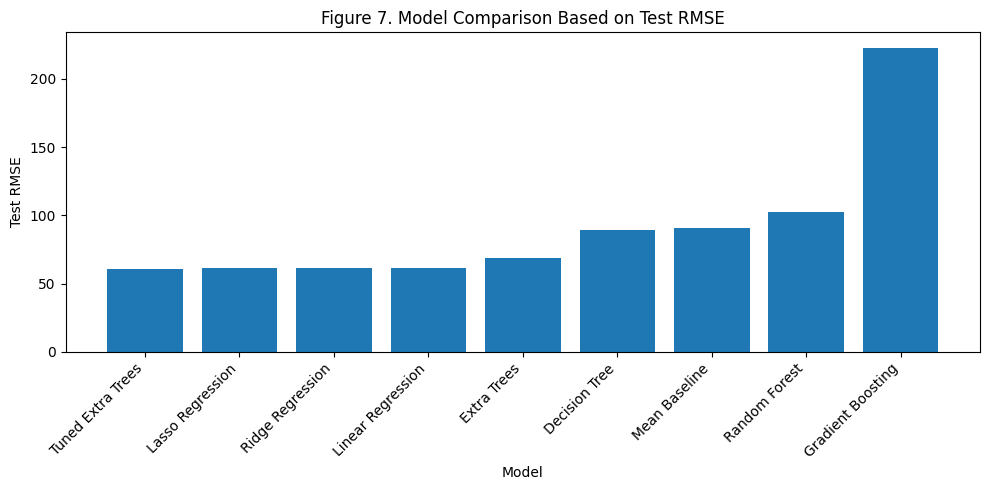

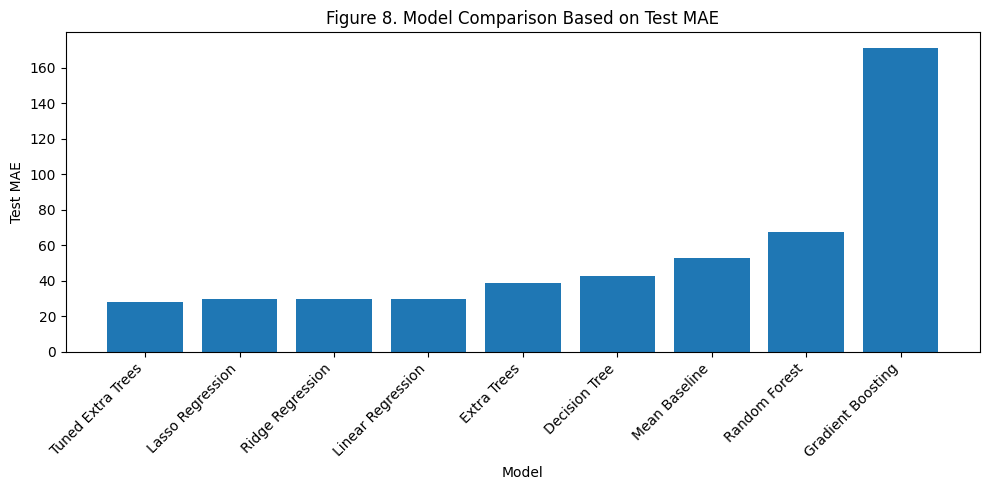

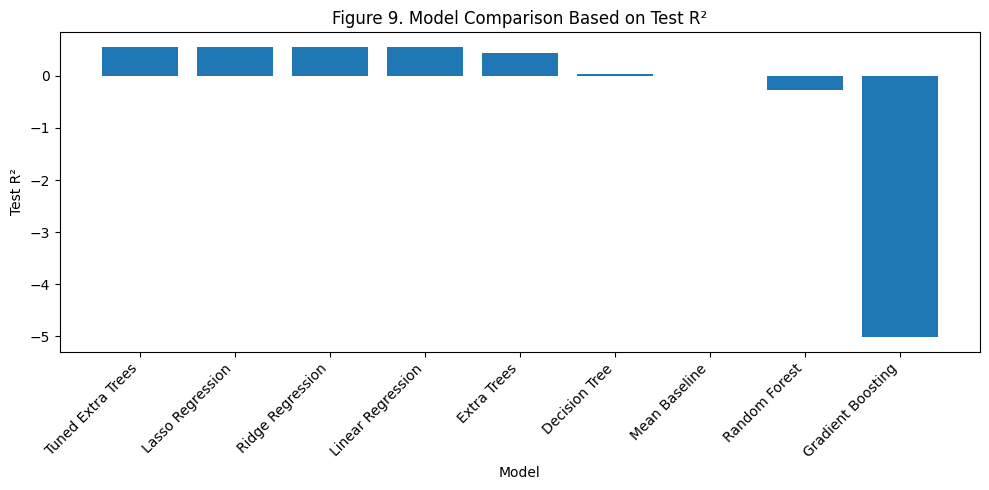

Best final model based on lowest test RMSE:


,Model,Split,MAE,MSE,RMSE,R2,Adjusted_R2,MAPE
0,Tuned Extra Trees,Test,27.941383,3672.278924,60.599331,0.555555,0.548844,24.820968


In [14]:
# I combine all model results so the final comparison is clear.

all_model_results_df = pd.concat(
    [
        baseline_linear_results_df,
        tree_results_df,
        tuned_results_df
    ],
    axis=0
).reset_index(drop=True)

final_test_results = all_model_results_df[
    all_model_results_df["Split"] == "Test"
].sort_values("RMSE").reset_index(drop=True)

display(all_model_results_df)
display(final_test_results)

all_model_results_df.to_csv(
    f"{OUTPUT_DIR}/table_16_all_model_results.csv",
    index=False
)

final_test_results.to_csv(
    f"{OUTPUT_DIR}/table_17_final_test_model_comparison.csv",
    index=False
)

plt.figure(figsize=(10, 5))
plt.bar(final_test_results["Model"], final_test_results["RMSE"])
plt.xlabel("Model")
plt.ylabel("Test RMSE")
plt.title("Figure 7. Model Comparison Based on Test RMSE")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure_7_model_comparison_rmse.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(final_test_results["Model"], final_test_results["MAE"])
plt.xlabel("Model")
plt.ylabel("Test MAE")
plt.title("Figure 8. Model Comparison Based on Test MAE")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure_8_model_comparison_mae.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(final_test_results["Model"], final_test_results["R2"])
plt.xlabel("Model")
plt.ylabel("Test R²")
plt.title("Figure 9. Model Comparison Based on Test R²")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure_9_model_comparison_r2.png", dpi=300)
plt.show()

print("Best final model based on lowest test RMSE:")
display(final_test_results.iloc[[0]])

,date,actual,predicted,residual,absolute_error,hour,weekday
0,2016-05-07 05:00:00,60,59.259944,0.740056,0.740056,5,5
1,2016-05-07 05:10:00,50,59.745143,-9.745143,9.745143,5,5
2,2016-05-07 05:20:00,50,54.260266,-4.260266,4.260266,5,5
3,2016-05-07 05:30:00,50,54.032419,-4.032419,4.032419,5,5
4,2016-05-07 05:40:00,50,52.693530,-2.693530,2.693530,5,5


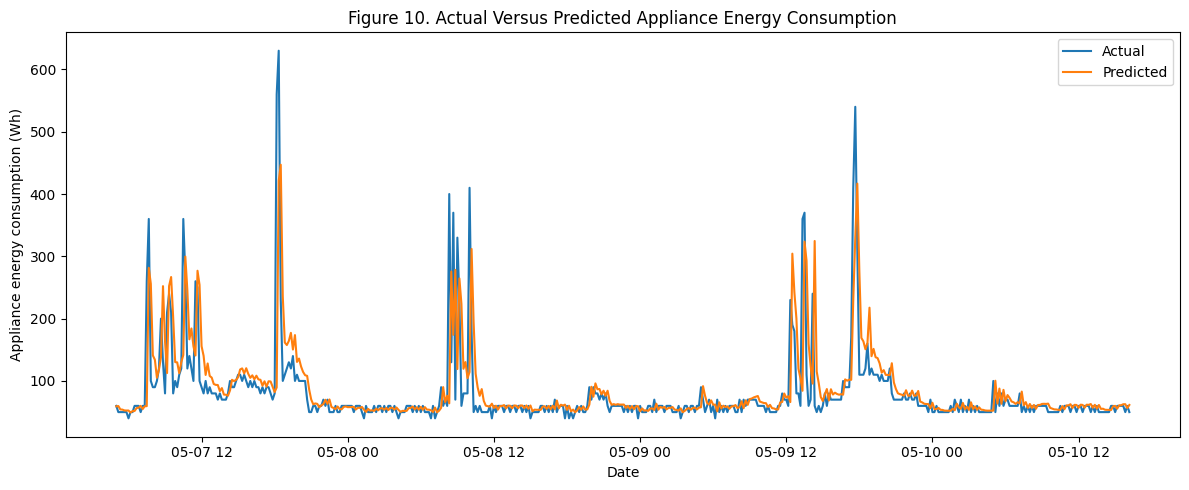

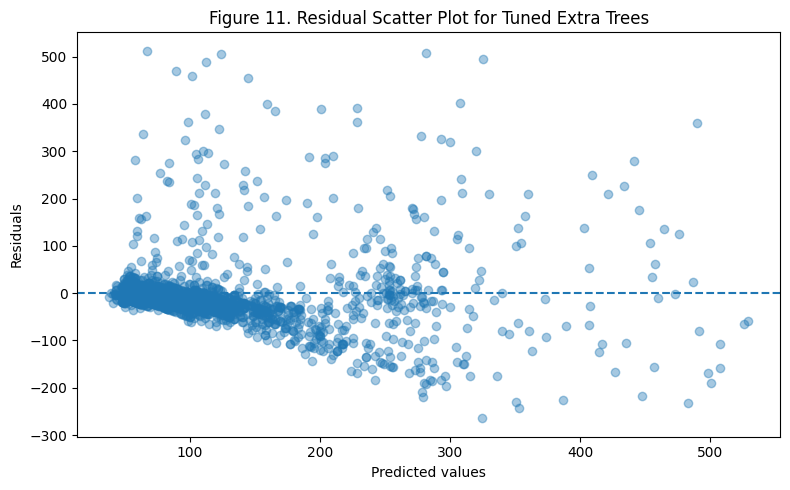

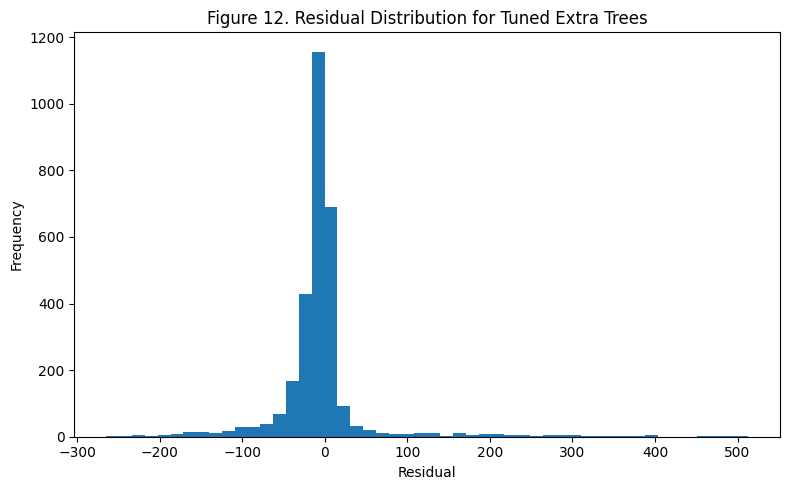

,hour,absolute_error
0,0,6.753783
1,1,5.964510
2,2,7.025665
3,3,6.602251
4,4,5.242524
5,5,15.377683
6,6,18.857848
7,7,28.985089
8,8,49.402064
9,9,46.734004


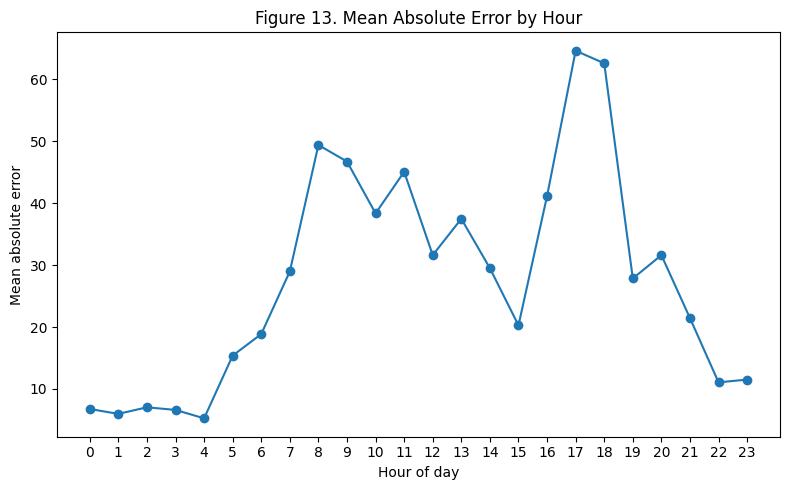

,usage_period,count,mean_actual,mean_predicted,MAE,RMSE
0,Normal usage,2649,70.939977,84.016095,17.796449,32.216802
1,Peak usage,310,319.225806,246.048231,114.631477,161.812487


In [15]:
# I now analyse the behaviour of the best final model in more detail.

best_model_name = "Tuned Extra Trees"
best_model = tuned_trained_models[best_model_name]
best_test_pred = tuned_model_predictions[best_model_name]["test"]

test_dates = model_data["date"].iloc[val_end:].reset_index(drop=True)

prediction_results = pd.DataFrame({
    "date": test_dates,
    "actual": y_test.reset_index(drop=True),
    "predicted": pd.Series(best_test_pred)
})

prediction_results["residual"] = prediction_results["actual"] - prediction_results["predicted"]
prediction_results["absolute_error"] = prediction_results["residual"].abs()
prediction_results["hour"] = prediction_results["date"].dt.hour
prediction_results["weekday"] = prediction_results["date"].dt.weekday

display(prediction_results.head())
prediction_results.to_csv(f"{OUTPUT_DIR}/table_18_best_model_predictions.csv", index=False)

plt.figure(figsize=(12, 5))
plt.plot(prediction_results["date"].iloc[:500], prediction_results["actual"].iloc[:500], label="Actual")
plt.plot(prediction_results["date"].iloc[:500], prediction_results["predicted"].iloc[:500], label="Predicted")
plt.xlabel("Date")
plt.ylabel("Appliance energy consumption (Wh)")
plt.title("Figure 10. Actual Versus Predicted Appliance Energy Consumption")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure_10_actual_vs_predicted.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(prediction_results["predicted"], prediction_results["residual"], alpha=0.4)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Figure 11. Residual Scatter Plot for Tuned Extra Trees")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure_11_residual_scatter.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(prediction_results["residual"], bins=50)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Figure 12. Residual Distribution for Tuned Extra Trees")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure_12_residual_distribution.png", dpi=300)
plt.show()

hourly_error = prediction_results.groupby("hour")["absolute_error"].mean().reset_index()
display(hourly_error)

hourly_error.to_csv(f"{OUTPUT_DIR}/table_19_hourly_error_analysis.csv", index=False)

plt.figure(figsize=(8, 5))
plt.plot(hourly_error["hour"], hourly_error["absolute_error"], marker="o")
plt.xlabel("Hour of day")
plt.ylabel("Mean absolute error")
plt.title("Figure 13. Mean Absolute Error by Hour")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure_13_hourly_error.png", dpi=300)
plt.show()

peak_threshold = y_test.quantile(0.90)

prediction_results["usage_period"] = np.where(
    prediction_results["actual"] >= peak_threshold,
    "Peak usage",
    "Normal usage"
)

peak_error_summary = prediction_results.groupby("usage_period").agg(
    count=("actual", "count"),
    mean_actual=("actual", "mean"),
    mean_predicted=("predicted", "mean"),
    MAE=("absolute_error", "mean"),
    RMSE=("residual", lambda x: np.sqrt(np.mean(x ** 2)))
).reset_index()

display(peak_error_summary)
peak_error_summary.to_csv(f"{OUTPUT_DIR}/table_20_peak_usage_error_analysis.csv", index=False)

,feature,importance
0,Appliances_lag_1,0.496098
1,Appliances_roll_3,0.202839
2,Appliances_roll_6,0.096646
3,Appliances_roll_12,0.093911
4,Appliances_lag_3,0.025094
5,hour,0.012072
6,Appliances_lag_6,0.010601
7,lights,0.006544
8,RH_1,0.002916
9,weekday,0.002406


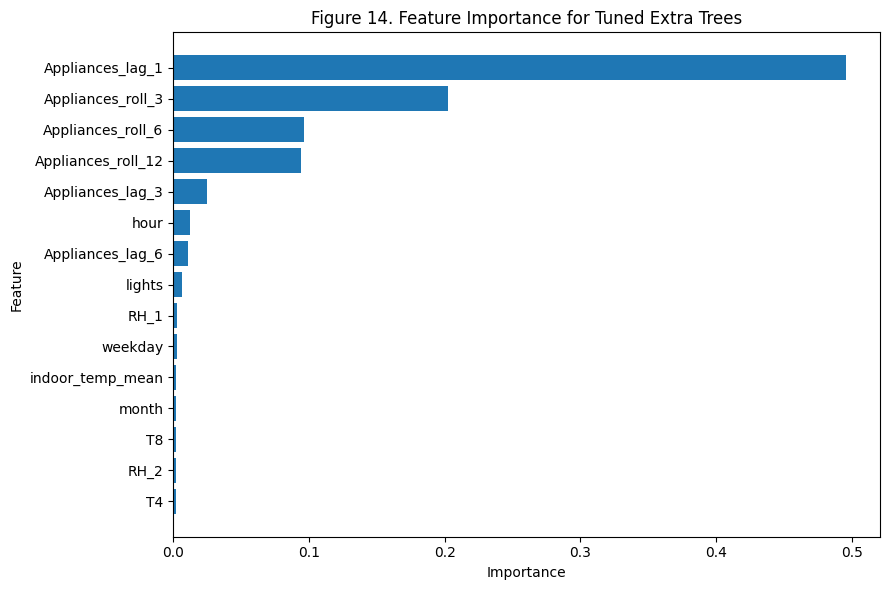

,feature,importance_mean,importance_std
0,Appliances_lag_1,0.637899,0.028740
1,Appliances_roll_3,0.045573,0.004399
2,Appliances_roll_12,0.011577,0.001963
3,Appliances_roll_6,0.008038,0.001587
4,Appliances_lag_3,0.004820,0.000913
5,hour,0.003418,0.000975
6,RH_9,0.000668,0.000280
7,Appliances_lag_6,0.000610,0.000322
8,lights,0.000415,0.000600
9,T3,0.000351,0.000221


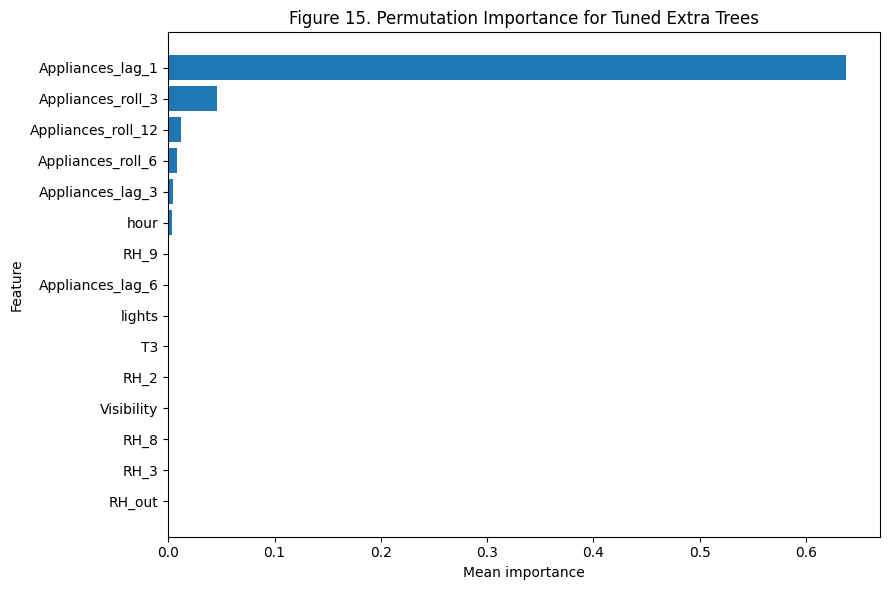

SHAP could not be generated in this environment.
Reason: No module named 'shap'


In [16]:
# I now explain which variables matter most in the best final model.

from sklearn.inspection import permutation_importance

best_model_name = "Tuned Extra Trees"
best_model = tuned_trained_models[best_model_name]

# Built-in feature importance
feature_importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_model.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

display(feature_importance_df.head(20))

feature_importance_df.to_csv(
    f"{OUTPUT_DIR}/table_21_feature_importance.csv",
    index=False
)

plt.figure(figsize=(9, 6))
plt.barh(
    feature_importance_df["feature"].head(15)[::-1],
    feature_importance_df["importance"].head(15)[::-1]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Figure 14. Feature Importance for Tuned Extra Trees")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure_14_feature_importance.png", dpi=300)
plt.show()

# Permutation importance
perm_result = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

permutation_importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

display(permutation_importance_df.head(20))

permutation_importance_df.to_csv(
    f"{OUTPUT_DIR}/table_22_permutation_importance.csv",
    index=False
)

plt.figure(figsize=(9, 6))
plt.barh(
    permutation_importance_df["feature"].head(15)[::-1],
    permutation_importance_df["importance_mean"].head(15)[::-1]
)
plt.xlabel("Mean importance")
plt.ylabel("Feature")
plt.title("Figure 15. Permutation Importance for Tuned Extra Trees")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure_15_permutation_importance.png", dpi=300)
plt.show()

# Optional SHAP analysis
try:
    import shap
    
    shap_sample = X_test.sample(n=min(1000, len(X_test)), random_state=RANDOM_STATE)
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(shap_sample)

    shap.summary_plot(shap_values, shap_sample, show=False)
    plt.title("Figure 16. SHAP Summary Plot for Tuned Extra Trees")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/figure_16_shap_summary_plot.png", dpi=300, bbox_inches="tight")
    plt.show()
    
    print("SHAP analysis completed successfully.")

except Exception as e:
    print("SHAP could not be generated in this environment.")
    print("Reason:", e)

Cross-validating: Linear Regression
Cross-validating: Ridge Regression
Cross-validating: Lasso Regression
Cross-validating: Extra Trees
Cross-validating: Tuned Extra Trees


,Model,Fold,MAE,RMSE,R2
0,Linear Regression,1,55.213290,80.233358,0.430815
1,Linear Regression,2,33.252581,67.733959,0.511387
2,Linear Regression,3,33.580935,68.593760,0.569665
3,Linear Regression,4,29.825029,65.461465,0.604544
4,Linear Regression,5,27.178560,58.520591,0.568458
5,Ridge Regression,1,55.461206,80.282798,0.430114
6,Ridge Regression,2,33.134275,67.658771,0.512471
7,Ridge Regression,3,33.427042,68.563044,0.570050
8,Ridge Regression,4,29.785352,65.461964,0.604538
9,Ridge Regression,5,27.158643,58.517416,0.568505


,Model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,Tuned Extra Trees,30.8004,4.9690,65.3260,4.8344,0.5743,0.0279
1,Extra Trees,35.1661,5.6642,67.0753,5.7487,0.5508,0.0445
2,Ridge Regression,35.7933,11.2932,68.0968,7.8679,0.5371,0.0683
3,Linear Regression,35.8101,11.1615,68.1086,7.8473,0.5370,0.0681
4,Lasso Regression,35.7988,11.2078,68.1113,7.8676,0.5369,0.0684


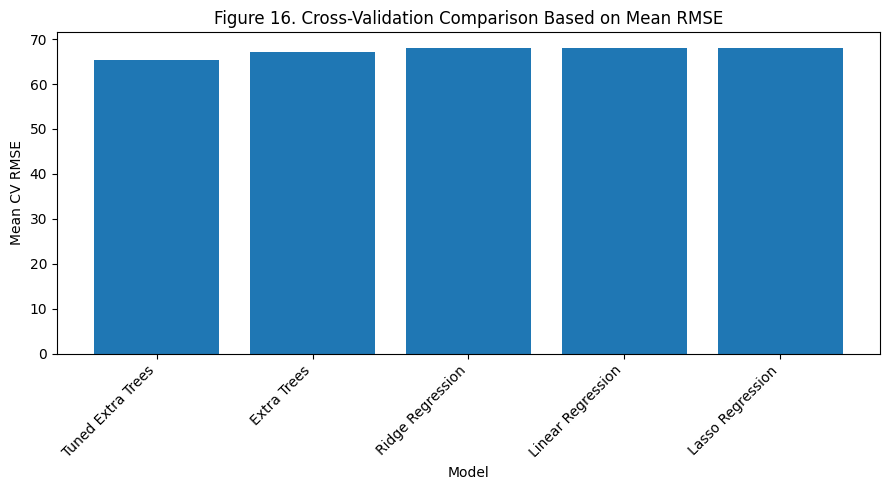

,Model,Test_MAE,Test_RMSE,Test_R2,Test_MAPE,Validation_RMSE,Train_RMSE,Generalisation_Gap,Rank_by_Test_RMSE
0,Tuned Extra Trees,27.941383,60.599331,0.555555,24.820968,60.122923,59.593520,1.005811,1
1,Lasso Regression,29.637798,61.186526,0.546900,28.081658,60.212600,67.336760,-6.150234,2
2,Ridge Regression,29.667182,61.200778,0.546689,28.121809,60.220900,67.336764,-6.135986,3
3,Linear Regression,29.731343,61.224002,0.546345,28.217024,60.222720,67.336740,-6.112738,4
4,Extra Trees,38.559732,68.694168,0.428887,38.145171,62.150011,22.992062,45.702106,5
5,Decision Tree,42.448701,89.206509,0.036892,37.935292,86.011094,47.068335,42.138173,6
6,Mean Baseline,52.834059,90.917091,-0.000399,58.956755,92.424654,106.795369,-15.878278,7
7,Random Forest,67.470089,102.395219,-0.268941,72.778145,71.611176,34.192649,68.202571,8
8,Gradient Boosting,171.227026,223.020276,-5.019643,224.419359,98.761672,52.796173,170.224103,9


,Rank_by_Test_RMSE,Model,Test_MAE,Test_RMSE,Test_R2,Test_MAPE
0,1,Tuned Extra Trees,27.941383,60.599331,0.555555,24.820968
1,2,Lasso Regression,29.637798,61.186526,0.546900,28.081658
2,3,Ridge Regression,29.667182,61.200778,0.546689,28.121809
3,4,Linear Regression,29.731343,61.224002,0.546345,28.217024
4,5,Extra Trees,38.559732,68.694168,0.428887,38.145171
5,6,Decision Tree,42.448701,89.206509,0.036892,37.935292
6,7,Mean Baseline,52.834059,90.917091,-0.000399,58.956755
7,8,Random Forest,67.470089,102.395219,-0.268941,72.778145
8,9,Gradient Boosting,171.227026,223.020276,-5.019643,224.419359


Best final model:


,Rank_by_Test_RMSE,Model,Test_MAE,Test_RMSE,Test_R2,Test_MAPE
0,1,Tuned Extra Trees,27.941383,60.599331,0.555555,24.820968


In [17]:
# I now check model stability with time-series cross-validation and prepare final summary tables.

from sklearn.model_selection import TimeSeriesSplit

# I use the development data only, so the test set stays untouched.
X_dev = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_dev = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

selected_models_for_cv = {
    "Linear Regression": baseline_and_linear_models["Linear Regression"],
    "Ridge Regression": baseline_and_linear_models["Ridge Regression"],
    "Lasso Regression": baseline_and_linear_models["Lasso Regression"],
    "Extra Trees": tree_models["Extra Trees"],
    "Tuned Extra Trees": extra_trees_search.best_estimator_
}

tscv_cv = TimeSeriesSplit(n_splits=5)

cv_rows = []

for model_name, model in selected_models_for_cv.items():
    print("Cross-validating:", model_name)
    
    fold_number = 1
    
    for train_index, val_index in tscv_cv.split(X_dev):
        X_cv_train = X_dev.iloc[train_index]
        X_cv_val = X_dev.iloc[val_index]
        y_cv_train = y_dev.iloc[train_index]
        y_cv_val = y_dev.iloc[val_index]
        
        model.fit(X_cv_train, y_cv_train)
        y_cv_pred = model.predict(X_cv_val)
        
        fold_mae = mean_absolute_error(y_cv_val, y_cv_pred)
        fold_rmse = np.sqrt(mean_squared_error(y_cv_val, y_cv_pred))
        fold_r2 = r2_score(y_cv_val, y_cv_pred)
        
        cv_rows.append({
            "Model": model_name,
            "Fold": fold_number,
            "MAE": fold_mae,
            "RMSE": fold_rmse,
            "R2": fold_r2
        })
        
        fold_number += 1

cv_results_df = pd.DataFrame(cv_rows)

display(cv_results_df)

cv_summary_df = cv_results_df.groupby("Model").agg({
    "MAE": ["mean", "std"],
    "RMSE": ["mean", "std"],
    "R2": ["mean", "std"]
}).round(4)

cv_summary_df.columns = [
    "MAE_mean", "MAE_std",
    "RMSE_mean", "RMSE_std",
    "R2_mean", "R2_std"
]

cv_summary_df = cv_summary_df.reset_index().sort_values("RMSE_mean").reset_index(drop=True)

display(cv_summary_df)

cv_results_df.to_csv(f"{OUTPUT_DIR}/table_23_cross_validation_fold_results.csv", index=False)
cv_summary_df.to_csv(f"{OUTPUT_DIR}/table_24_cross_validation_summary.csv", index=False)

plt.figure(figsize=(9, 5))
plt.bar(cv_summary_df["Model"], cv_summary_df["RMSE_mean"])
plt.xlabel("Model")
plt.ylabel("Mean CV RMSE")
plt.title("Figure 16. Cross-Validation Comparison Based on Mean RMSE")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure_16_cross_validation_rmse.png", dpi=300)
plt.show()

# I now prepare one clean final comparison table for the report.
train_results = all_model_results_df[all_model_results_df["Split"] == "Train"].copy()
validation_results = all_model_results_df[all_model_results_df["Split"] == "Validation"].copy()
test_results = all_model_results_df[all_model_results_df["Split"] == "Test"].copy()

final_summary_table = test_results[[
    "Model", "MAE", "RMSE", "R2", "MAPE"
]].copy()

final_summary_table = final_summary_table.rename(columns={
    "MAE": "Test_MAE",
    "RMSE": "Test_RMSE",
    "R2": "Test_R2",
    "MAPE": "Test_MAPE"
})

final_summary_table["Validation_RMSE"] = final_summary_table["Model"].map(
    validation_results.set_index("Model")["RMSE"]
)

final_summary_table["Train_RMSE"] = final_summary_table["Model"].map(
    train_results.set_index("Model")["RMSE"]
)

final_summary_table["Generalisation_Gap"] = (
    final_summary_table["Test_RMSE"] - final_summary_table["Train_RMSE"]
)

final_summary_table["Rank_by_Test_RMSE"] = final_summary_table["Test_RMSE"].rank(method="dense").astype(int)

final_summary_table = final_summary_table.sort_values("Test_RMSE").reset_index(drop=True)

display(final_summary_table)

final_summary_table.to_csv(f"{OUTPUT_DIR}/table_25_final_report_summary_table.csv", index=False)

# I also prepare a compact literature-style table for the main report.
report_table = final_summary_table[[
    "Rank_by_Test_RMSE",
    "Model",
    "Test_MAE",
    "Test_RMSE",
    "Test_R2",
    "Test_MAPE"
]].copy()

report_table = report_table.sort_values("Rank_by_Test_RMSE").reset_index(drop=True)

display(report_table)

report_table.to_csv(f"{OUTPUT_DIR}/table_26_report_ready_model_table.csv", index=False)

print("Best final model:")
display(report_table.iloc[[0]])